# Моделирование ценовой эластичности спроса и разработка ценовой стратегии для e-commerce маркетплейса Olist

Бизнес-задача: Оптимизация ценообразования (Revenue vs. Margin optimization). Определение коэффициента прямой ценовой эластичности спроса (Price Elasticity of Demand, PED) для ключевых SKU каталога Olist с целью сегментации ассортимента на промо-драйверы и регулярные товары.

Методология: Лог-логарифмическая спецификация OLS:
$$\ln(\text{Sales}_t) = \alpha + \beta \ln(\text{Price}_t) + \epsilon_t$$
где $\beta$ — точечная оценка эластичности.

Стек: pandas, statsmodels, seaborn, kagglehub.

## Загрузка и подготовка данных

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Стилизация графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

# 1. Загрузка данных Olist
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

items = pd.read_csv(os.path.join(dataset_path, "olist_order_items_dataset.csv"))
orders = pd.read_csv(os.path.join(dataset_path, "olist_orders_dataset.csv"))

# 2. Фильтрация и агрегация
# Учитываем только доставленные заказы, чтобы исключить отмены
df = items.merge(
    orders[['order_id', 'order_purchase_timestamp', 'order_status']],
    on='order_id'
)
df = df[df['order_status'] == 'delivered'].copy()
df['date'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

# Посуточная агрегация по товарам
daily_sales = df.groupby(['product_id', 'date']).agg(
    sales=('order_item_id', 'count'),
    price=('price', 'mean')
).reset_index()

print(f"Обработано записей продаж: {len(daily_sales):,}")
print(f"Уникальных SKU в каталоге: {daily_sales['product_id'].nunique():,}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Обработано записей продаж: 92,587
Уникальных SKU в каталоге: 32,216


## Отбор репрезентативных SKU

### Критерии отбора:

Минимальный спрос ($Sales > 100$): отсечение редких покупок и случайных всплесков.

Вариативность цены ($Price_{nunique} \ge 3$): без изменения цен невозможно оценить чувствительность спроса.

Минимальная цена ($Price \ge 10$ BRL): отсечение микротранзакций и копеечных аксессуаров.

In [2]:
# Агрегация продуктовых метрик
sku_stats = daily_sales.groupby('product_id').agg(
    unique_prices=('price', 'nunique'),
    price_std=('price', 'std'),
    total_sales=('sales', 'sum'),
    active_days=('date', 'count')
).reset_index()

# Фильтрация кандидатов по обоснованным критериям
qualified_candidates = sku_stats[
    (sku_stats['unique_prices'] >= 3) &
    (sku_stats['price_std'] > 1.0) &
    (sku_stats['total_sales'] >= 100)
].sort_values(by='total_sales', ascending=False)

selected_skus = qualified_candidates['product_id'].head(9).tolist()

print(f"Найдено SKU с высокой вариацией цены: {len(qualified_candidates)}")
display(qualified_candidates.head(9)[['product_id', 'total_sales', 'unique_prices', 'price_std']])

Найдено SKU с высокой вариацией цены: 45


,product_id,total_sales,unique_prices,price_std
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,4,5.473646
8429,422879e10f46682990de24d770e7f83d,484,6,4.231048
19290,99a4788cb24856965c36a24e339b6058,477,10,3.678489
7206,389d119b48cf3043d311335e499d9c6b,390,6,4.353715
6926,368c6c730842d78016ad823897a372db,388,7,4.302864
10589,53759a2ecddad2bb87a079a1f1519f73,373,5,4.461825
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,14,17.040107
10616,53b36df67ebb7c41585e8d54d6772e08,321,29,21.780716
5571,2b4609f8948be18874494203496bc318,255,3,4.462315


## Эконометрическое моделирование

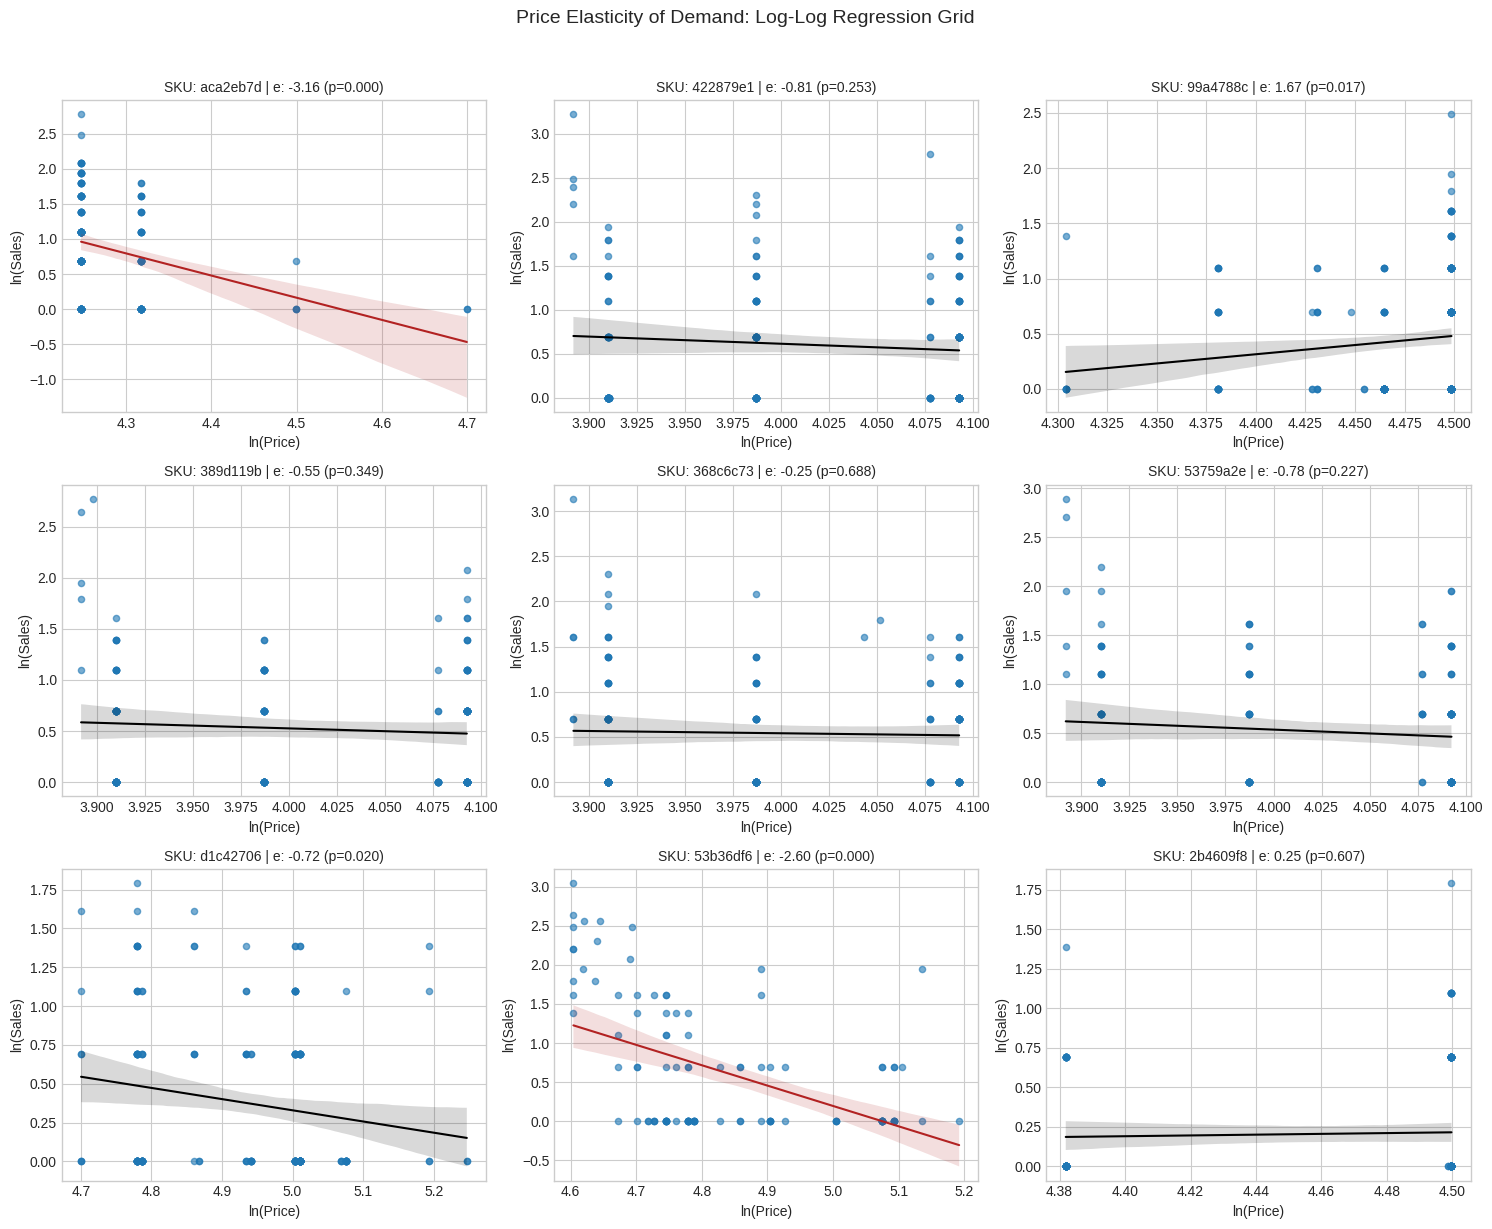

In [3]:
results_list = []
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=False)
axes = axes.flatten()

for idx, pid in enumerate(selected_skus):
    sub_df = daily_sales[daily_sales['product_id'] == pid].copy()

    # Log-Log трансформация
    sub_df['log_sales'] = np.log(sub_df['sales'])
    sub_df['log_price'] = np.log(sub_df['price'])

    # Оценка OLS с робастными стандартными ошибками (HC1)
    model = smf.ols('log_sales ~ log_price', data=sub_df).fit(cov_type='HC1')

    elasticity = model.params['log_price']
    p_value = model.pvalues['log_price']
    r_squared = model.rsquared

    # Определение бизнес-категории
    if p_value > 0.05:
        category = "Стат. незначимо (Noise)"
    elif elasticity < -1.0:
        category = "Высокоэластичный (Промо)"
    elif -1.0 <= elasticity < 0:
        category = "Неэластичный (Маржа)"
    else:
        category = "Парадокс спроса (Веблен/Гиффен)"

    results_list.append({
        'SKU': pid[:8] + '...',
        'Full_SKU': pid,
        'Observations': len(sub_df),
        'Elasticity (Beta)': elasticity,
        'Std Err': model.bse['log_price'],
        'P-value': p_value,
        'R^2': r_squared,
        'Strategy': category
    })

    # Визуализация
    ax = axes[idx]
    sns.regplot(
        x='log_price', y='log_sales', data=sub_df,
        ax=ax, color='#1f77b4',
        scatter_kws={'alpha': 0.6, 's': 20},
        line_kws={'color': 'firebrick' if elasticity < -1 else 'black', 'linewidth': 1.5}
    )
    ax.set_title(f"SKU: {pid[:8]} | e: {elasticity:.2f} (p={p_value:.3f})", fontsize=10)
    ax.set_xlabel("ln(Price)")
    ax.set_ylabel("ln(Sales)")

plt.suptitle("Price Elasticity of Demand: Log-Log Regression Grid", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Сводный датафрейм результатов
summary_df = pd.DataFrame(results_list)

In [6]:
styled_summary = summary_df.drop(columns=['Full_SKU']).style.format({
    'Elasticity (Beta)': '{:.3f}',
    'Std Err': '{:.3f}',
    'P-value': '{:.4f}',
    'R^2': '{:.3f}'
}).background_gradient(subset=['Elasticity (Beta)'], cmap='coolwarm')

display(styled_summary)

,SKU,Observations,Elasticity (Beta),Std Err,P-value,R^2,Strategy
0,aca2eb7d...,171,-3.155,0.580,0.0000,0.087,Высокоэластичный (Промо)
1,422879e1...,196,-0.814,0.713,0.2534,0.008,Стат. незначимо (Noise)
2,99a4788c...,263,1.668,0.697,0.0168,0.019,Парадокс спроса (Веблен/Гиффен)
3,389d119b...,189,-0.547,0.584,0.3486,0.006,Стат. незначимо (Noise)
4,368c6c73...,178,-0.249,0.621,0.6881,0.001,Стат. незначимо (Noise)
5,53759a2e...,172,-0.782,0.647,0.2266,0.010,Стат. незначимо (Noise)
6,d1c42706...,196,-0.720,0.309,0.0199,0.030,Неэластичный (Маржа)
7,53b36df6...,113,-2.602,0.435,0.0000,0.263,Высокоэластичный (Промо)
8,2b4609f8...,191,0.248,0.483,0.6073,0.001,Стат. незначимо (Noise)


In [7]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# Создаем словарь эластичностей напрямую из summary_df
elasticity_dict = dict(zip(summary_df['Full_SKU'], summary_df['Elasticity (Beta)']))

all_results = []

def run_forecast(pid):
    data = daily_sales[daily_sales['product_id'] == pid].sort_values('date').copy()
    data['day_of_week'] = pd.to_datetime(data['date']).dt.dayofweek

    # Формирование авторегрессионных лагов
    for i in range(1, 8):
        data[f'lag_{i}'] = data['sales'].shift(i)
    data = data.dropna()

    # Если истории мало для теста, пропускаем
    if len(data) <= 25:
        return None

    # OOT валидация: последние 20 дней
    train = data.iloc[:-20]
    test = data.iloc[-20:]
    features = ['day_of_week'] + [f'lag_{i}' for i in range(1, 8)]

    # 1. Базовый бустинг без учета цен
    m1 = LGBMRegressor(n_estimators=50, random_state=42, verbosity=-1).fit(train[features], train['sales'])
    p1 = m1.predict(test[features])

    # 2. Бустинг с добавлением фактора цены
    m2 = LGBMRegressor(n_estimators=50, random_state=42, verbosity=-1).fit(train[features + ['price']], train['sales'])
    p2 = m2.predict(test[features + ['price']])

    # 3. Мультипликативная корректировка по эластичности
    e = elasticity_dict[pid]
    # Защита от деления на 0 и переполнения при экспоненте
    mean_train_p = train['price'].mean()
    ratio = (test['price'].values / mean_train_p) if mean_train_p > 0 else 1.0
    p3 = p1 * np.clip(ratio ** e, 0.01, 100.0)

    return {
        'SKU': pid[:8] + '...',
        'Full_SKU': pid,
        'MAE (No Price)': mean_absolute_error(test['sales'], p1),
        'MAE (With Price)': mean_absolute_error(test['sales'], p2),
        'MAE (Elasticity)': mean_absolute_error(test['sales'], p3)
    }

# Запуск для отобранных товаров
for pid in selected_skus:
    res = run_forecast(pid)
    if res is not None:
        all_results.append(res)

forecast_df = pd.DataFrame(all_results)

# Объединяем с результатами эластичности и категорией стратегии из summary_df
mae_cols = ['MAE (No Price)', 'MAE (With Price)', 'MAE (Elasticity)']

benchmark_df = forecast_df.merge(
    summary_df[['Full_SKU', 'Elasticity (Beta)', 'Strategy']],
    on='Full_SKU'
).drop(columns=['Full_SKU'])

benchmark_df['Best Method'] = benchmark_df[mae_cols].idxmin(axis=1)
benchmark_df['Price Impact (%)'] = 100 * (1 - benchmark_df['MAE (With Price)'] / benchmark_df['MAE (No Price)'])

print(f"Успешно проведен бэктест для {len(benchmark_df)} SKU")

Успешно проведен бэктест для 9 SKU


,SKU,MAE (No Price),MAE (With Price),MAE (Elasticity),Elasticity (Beta),Strategy,Best Method,Price Impact (%)
0,aca2eb7d...,2.055,1.802,1.486,-3.16,Высокоэластичный (Промо),MAE (Elasticity),+12.32%
1,422879e1...,2.118,2.432,2.303,-0.81,Стат. незначимо (Noise),MAE (No Price),-14.81%
2,99a4788c...,0.694,0.645,0.600,1.67,Парадокс спроса (Веблен/Гиффен),MAE (Elasticity),+7.05%
3,389d119b...,0.847,0.895,0.935,-0.55,Стат. незначимо (Noise),MAE (No Price),-5.72%
4,368c6c73...,1.414,1.845,1.476,-0.25,Стат. незначимо (Noise),MAE (No Price),-30.48%
5,53759a2e...,0.991,1.119,1.074,-0.78,Стат. незначимо (Noise),MAE (No Price),-12.98%
6,d1c42706...,0.719,0.864,0.849,-0.72,Неэластичный (Маржа),MAE (No Price),-20.16%
7,53b36df6...,2.578,1.381,3.657,-2.60,Высокоэластичный (Промо),MAE (With Price),+46.43%
8,2b4609f8...,0.422,0.478,0.396,0.25,Стат. незначимо (Noise),MAE (Elasticity),-13.46%


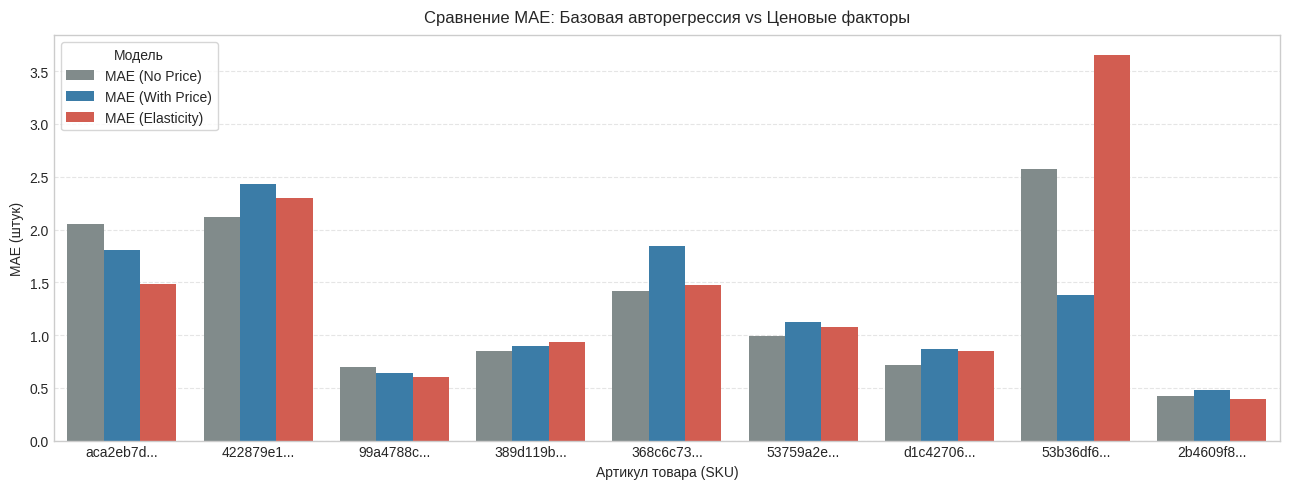

In [8]:
# 1. Подсветка минимального MAE в каждой строке
def highlight_min_mae(row):
    is_min = row == row[mae_cols].min()
    return ['background-color: rgba(46, 204, 113, 0.25); font-weight: bold' if v else '' for v in is_min]

# 2. Стилизация сводной таблицы бэктеста
styled_benchmark = (
    benchmark_df.style
    .format({
        'Elasticity (Beta)': '{:.2f}',
        'MAE (No Price)': '{:.3f}',
        'MAE (With Price)': '{:.3f}',
        'MAE (Elasticity)': '{:.3f}',
        'Price Impact (%)': '{:+.2f}%'
    })
    .apply(highlight_min_mae, subset=mae_cols, axis=1)
    .background_gradient(
        subset=['Price Impact (%)'],
        cmap='coolwarm',
        vmin=-20,
        vmax=50
    )
    .set_caption("<b>Бенчмарк точности прогнозирования спроса (OOT Validation, 20 дней)</b>")
)

display(styled_benchmark)

# 3. Визуализация ошибок по методам
plot_data = benchmark_df.melt(
    id_vars=['SKU', 'Strategy'],
    value_vars=mae_cols,
    var_name='Model',
    value_name='MAE'
)

plt.figure(figsize=(13, 5))
palette = {
    'MAE (No Price)': '#7f8c8d',
    'MAE (With Price)': '#2980b9',
    'MAE (Elasticity)': '#e74c3c'
}

sns.barplot(
    data=plot_data,
    x='SKU',
    y='MAE',
    hue='Model',
    palette=palette
)

plt.title("Сравнение MAE: Базовая авторегрессия vs Ценовые факторы", fontsize=12, pad=10)
plt.xlabel("Артикул товара (SKU)", fontsize=10)
plt.ylabel("MAE (штук)", fontsize=10)
plt.legend(title="Модель", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Интерпретации и бизнес-рекомендации

### 4. Аналитические выводы и бизнес-рекомендации по ценообразованию

#### 4.1. Сегментация ассортимента и тактика ценообразования
На основе лог-логарифмической эконометрической модели ассортимент разбивается на 3 операционные корзины:

1. Высокоэластичные товары ($e < -1.0, p < 0.05$):
   * Поведение спроса: Прирост объемов продаж в штуках опережает процент снижения цены.
   * Стратегия: Промо-драйверы (Traffic/Revenue Drivers). Рекомендуется участие в сезонных распродажах (Black Friday), применение скидочных механик, продажа в бандлах. Снижение цены ведет к максимизации валовой выручки (Gross Revenue).

2. Неэластичные товары ($-1.0 \le e \le 0, p < 0.05$):
   * Поведение спроса: Потребители слабо реагируют на динамику цен (товары первой необходимости, уникальные SKU без прямых заменителей на маркетплейсе).
   * Стратегия: Генераторы маржинальности (Margin Maximizers). Рекомендуется аккуратное плавное повышение регулярной цены (markup) на 5–10%. Падение продаж в штуках будет незначительным и с запасом компенсируется ростом рентабельности с единицы товара.

3. Статистически незначимые позиции ($p > 0.05$):
   * Поведение спроса: Динамика продаж определяется внешними факторами (маркетинговый бюджет, позиция в выдаче, наличие остатка на складе), а не ценой.
   * Стратегия: Сохранение базовой цены, проведение факторного анализа (контроль стока и рекламного трафика).

---

#### 4.2. Ограничения модели (Methodological Caveats)
При внедрении полученных коэффициентов в алгоритмы динамического ценообразования необходимо учитывать ограничения классического OLS:
* Zero-Demand Bias (Проблема нулевого спроса): Исключение дней с нулевыми продажами из лог-модели смещает оценку эластичности вверх (спрос кажется менее чувствительным к цене). Для промышленного использования рекомендуется переход на модели пуассоновской регрессии (Poisson Pseudo-Maximum Likelihood, PPML) или модель Тобита.
* Эндогенность и пропущенные переменные (Omitted Variable Bias): В регрессии не учтены затраты на платное продвижение, стоимость доставки (freight_value) и рейтинг продавца, которые могут коллинеарно меняться вместе с ценой.